In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import shapely.wkt
from ipyleaflet import Map, GeoData, basemaps, LayersControl

In [2]:
R3_1_respondents = pd.read_excel('MaptionnaireR3_results_2025-01-03.xlsx', sheet_name='Respondents')
R3_1_geo = pd.read_excel('MaptionnaireR3_results_2025-01-03.xlsx', sheet_name='Click on map to draw polygon an')
R3_2_respondents = pd.read_excel('MaptionnaireR3_results_2025-02-10.xlsx', sheet_name='Respondents')
R3_2_geo = pd.read_excel('MaptionnaireR3_results_2025-02-10.xlsx', sheet_name='Click on map to draw polygon an')

In [3]:
respondents_full = pd.concat([R3_1_respondents, R3_2_respondents])
geo_full = pd.concat([R3_1_geo, R3_2_geo])

In [4]:
SA_bndry = gpd.read_file("shps/SA_bndry/All Study Area Boundaries.shp")
SA_bndry = SA_bndry.to_crs("EPSG:4326")


In [5]:
area_counts = respondents_full['Select a Study Area to explore updates from Round 2:'].value_counts().reset_index()
area_counts.columns = ['Study Area', 'count']
total_counts = pd.DataFrame([{'Study Area': 'total', 'count': area_counts['count'].sum()}])
bar_counts = area_counts[area_counts['Study Area'] != 'I would like to skip to the end of the survey to provide general comments on the citywide map']

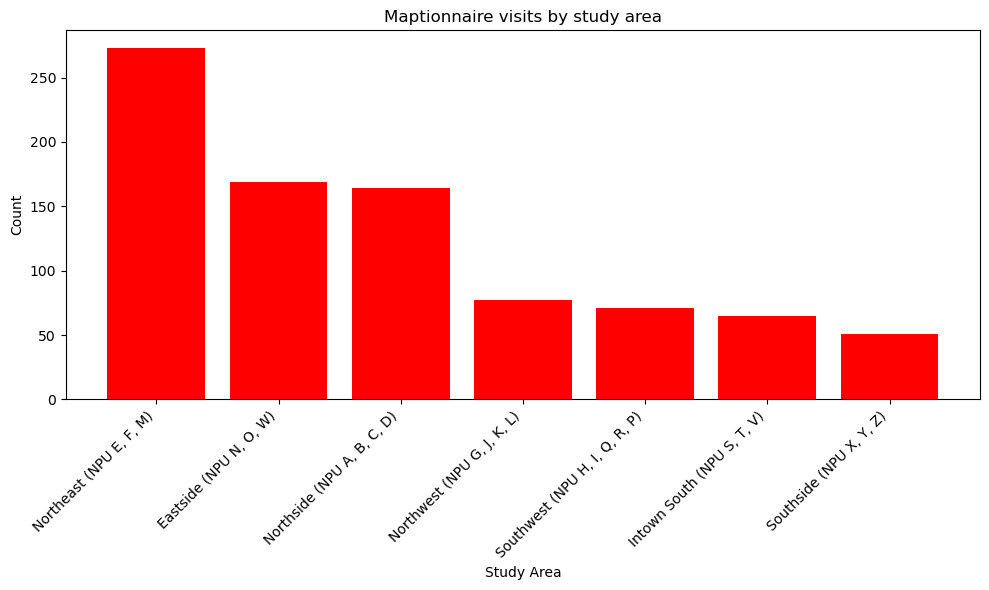

In [6]:
plt.figure(figsize=(10,6))
plt.bar(bar_counts['Study Area'], bar_counts['count'], color='red')
plt.xlabel('Study Area')
plt.ylabel('Count')
plt.title('Maptionnaire visits by study area')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [7]:
# Filter out rows with NaN or invalid WKT values
geo_full = geo_full.dropna(subset=['WKT'])
# Filter out invalid WKT values
geo_full = geo_full[geo_full['WKT'].apply(lambda x: shapely.wkt.loads(x) is not None if x else False)]

geo_full['geometry'] = geo_full['WKT'].apply(shapely.wkt.loads)
geo_full_gdf = gpd.GeoDataFrame(geo_full, geometry='geometry', crs="EPSG:4326")

In [8]:
geo_full_gdf['time'] = geo_full_gdf['First Active Time']
geo_full_gdf['comment'] = geo_full_gdf['Add place-specific comment below:']

geo_full_gdf = geo_full_gdf[['time', 'comment', 'geometry']]

In [9]:
# Convert Timestamp objects to strings
geo_full_gdf['time'] = geo_full_gdf['time'].astype(str)

In [10]:
m = Map(center=(33.758200949064495, -84.42296856673084), zoom=11, scroll_wheel_zoom=True, basemap=basemaps.CartoDB.Positron, attribution_control=False)

SA_lyr = GeoData(geo_dataframe = SA_bndry,
                   style={'color': 'black', 'fillColor': 'transparent', 'opacity':1, 'weight':0.5, 'fillOpacity':0.6},
                   hover_style={'fillColor': 'transparent' , 'fillOpacity': 0.2},
                   name = 'Study Area Boundaries')
R3_lyr = GeoData(geo_dataframe = geo_full_gdf,
                   style={'color': 'black', 'fillColor': 'red', 'opacity':0.05, 'weight':1.9, 'dashArray':'2', 'fillOpacity':0.3},
                   hover_style={'fillColor': 'red' , 'fillOpacity': 0.2},
                   name = 'Round 3 Comments')

m.add(SA_lyr)
m.add(R3_lyr)

Map(center=[33.758200949064495, -84.42296856673084], controls=(ZoomControl(options=['position', 'zoom_in_text'…

In [13]:
geo_full.to_csv("R3_comments.csv")
geo_full_gdf.to_file("R3.kml", driver="KML")

DriverError: unsupported driver: 'KML'